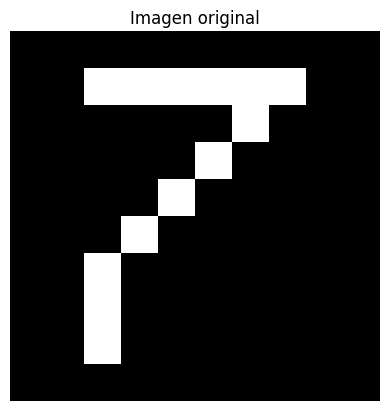

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Creamos una imagen sencilla de 10x10 píxeles.
# Los valores 0 representan el fondo negro.
# Los valores 1 representan los píxeles blancos.

imagen = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,1,1,1,0,0],
    [0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,1,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]
])

#Cuando se imprime la matriz, el valor es claro para nosotros que es un 7, pero para la computadora no

plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

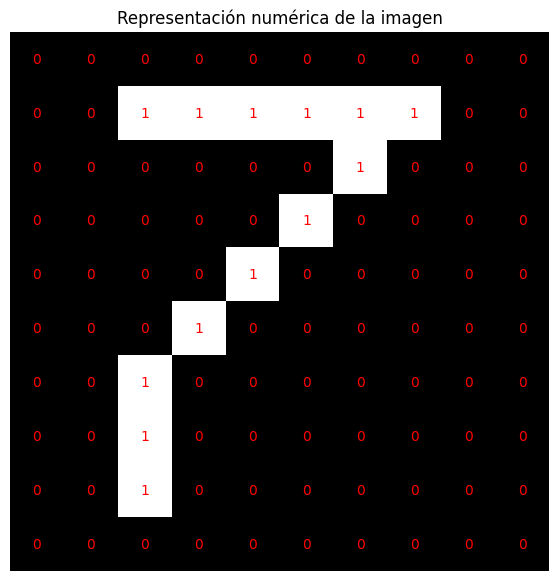

In [2]:
plt.figure(figsize=(7,7))

plt.imshow(imagen, cmap="gray")

# Escribimos el valor numérico de cada píxel
# encima de la imagen para visualizar la matriz.

for i in range(imagen.shape[0]):
    for j in range(imagen.shape[1]):
        plt.text(
            j, i,
            imagen[i, j],
            ha="center",
            va="center",
            color="red"
        )

plt.title("Representación numérica de la imagen")
plt.axis("off")
plt.show()

In [3]:
# Un kernel es una pequeña matriz que recorre la imagen.
#
# Este kernel de 3x3 sirve como ejemplo para detectar
# cambios de intensidad relacionados con bordes verticales.

kernel_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

print("Kernel:")
print(kernel_vertical)

Kernel:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


**Ejemplo de una convolución**

In [ ]:
def convolucion(imagen, kernel):

    # Obtenemos las dimensiones de la imagen
    alto_imagen, ancho_imagen = imagen.shape

    # Obtenemos las dimensiones del kernel
    alto_kernel, ancho_kernel = kernel.shape

    # Calculamos el tamaño que tendrá el Feature Map.
    #
    # Como el kernel es de 3x3 y nuestra imagen de 10x10,
    # el resultado será de 8x8.
    alto_salida = alto_imagen - alto_kernel + 1
    ancho_salida = ancho_imagen - ancho_kernel + 1

    # Creamos inicialmente una matriz llena de ceros.
    feature_map = np.zeros((alto_salida, ancho_salida))

    # El kernel se desplaza por toda la imagen.
    for i in range(alto_salida):
        for j in range(ancho_salida):

            # Seleccionamos la región de la imagen
            # que actualmente está observando el kernel.
            region = imagen[
                i:i + alto_kernel,
                j:j + ancho_kernel
            ]

            # Multiplicamos cada píxel de la región
            # por el valor correspondiente del kernel
            # y después sumamos todos los resultados.
            feature_map[i, j] = np.sum(region * kernel)

    return feature_map